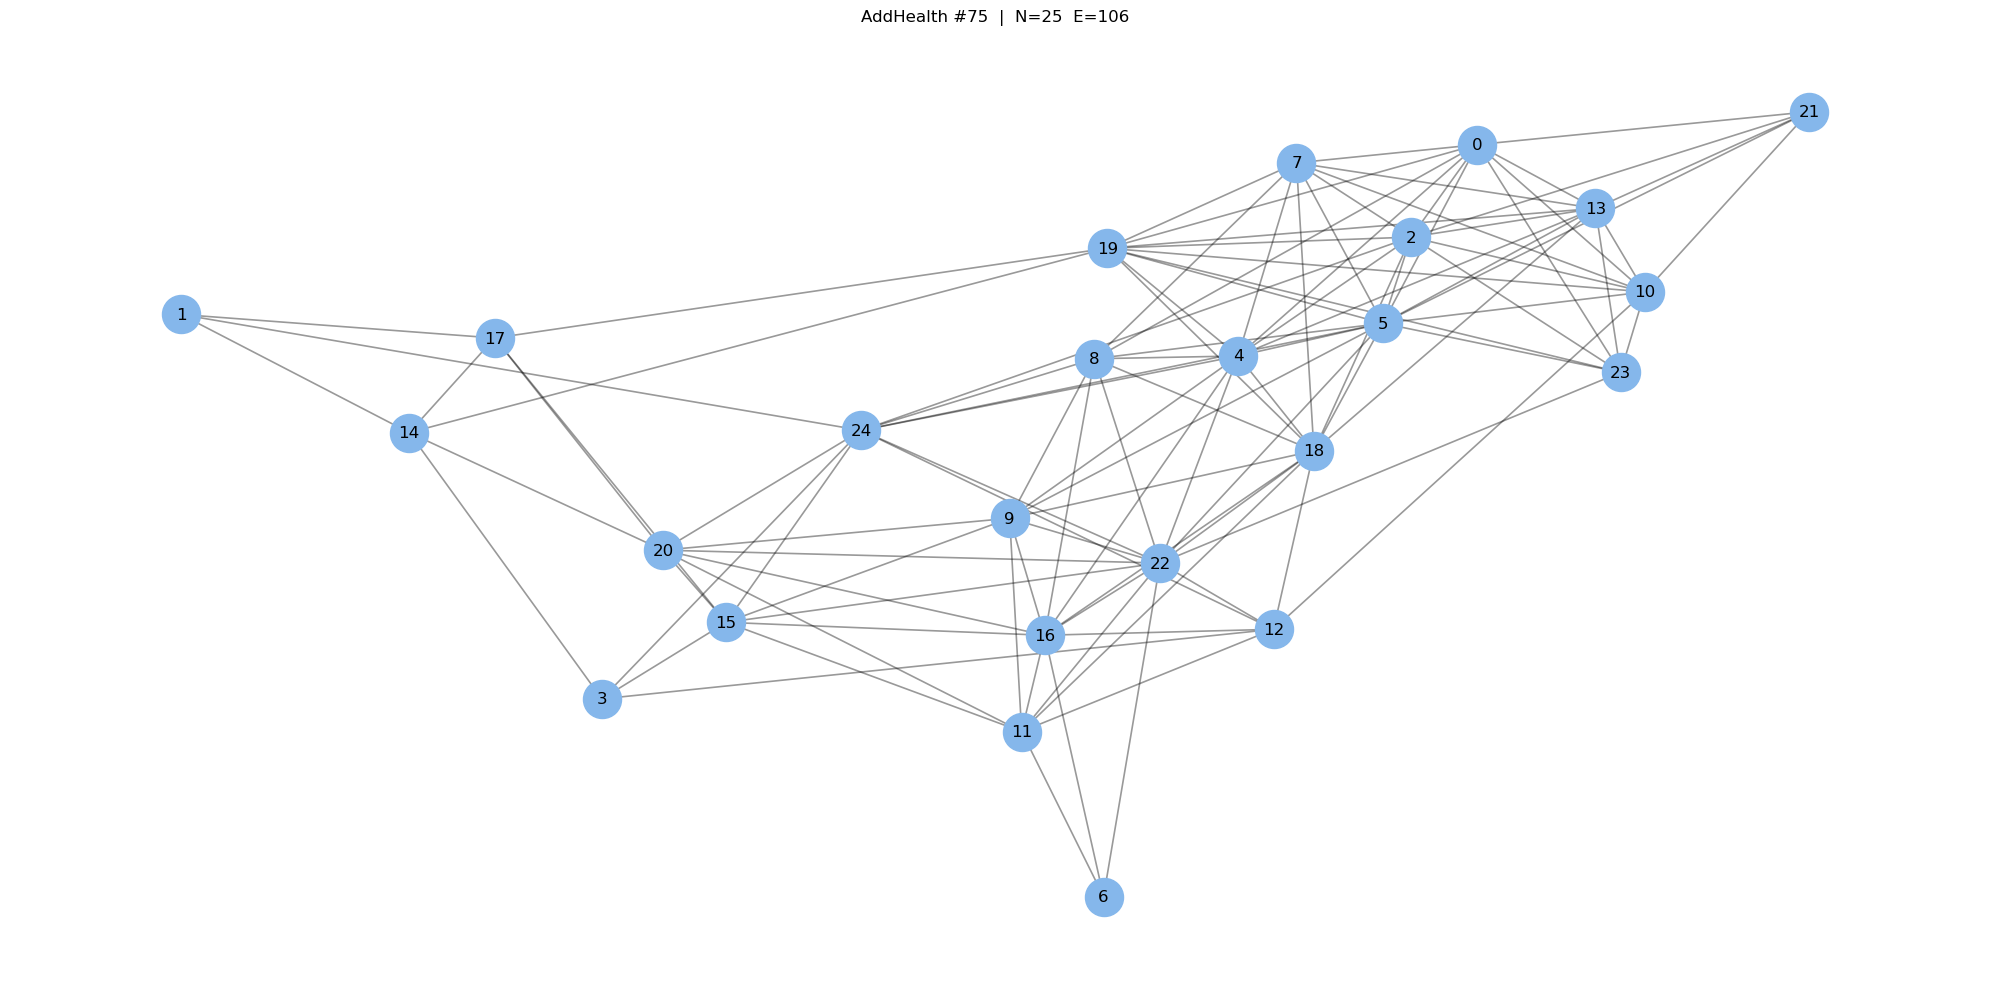

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

mat = pd.read_csv("/mnt/f/test1/addhealth_net_75.csv", header=0).values
g = nx.from_numpy_array(mat)   # گره‌ها 0 تا 24

pos = nx.spring_layout(g, seed=7, k=2.0, iterations=200)

fig, ax = plt.subplots(figsize=(20, 10))
nx.draw_networkx_edges(g, pos, alpha=0.4, width=1.2, ax=ax)
nx.draw_networkx_nodes(g, pos, node_size=750, node_color="#85B7EB", linewidths=1, ax=ax)
nx.draw_networkx_labels(g, pos, font_size=12, font_weight="normal", ax=ax)

ax.axis("off")
#plt.savefig("/mnt/f/test/addhealth75.png", dpi=150, bbox_inches="tight")
ax.set_title(f"AddHealth #75  |  N={g.number_of_nodes()}  E={g.number_of_edges()}")
plt.tight_layout()
plt.show()

In [4]:
v = 12       # گره موردنظر
d = 3        # فاصله برای محاسبه CI

# 1. Degree
degree = dict(g.degree())

max_degree = max(degree.values())
best_degree_nodes = [node for node, value in degree.items() if value == max_degree]

# 2. Betweenness Centrality
betweenness = nx.betweenness_centrality(g, normalized=False)

max_betweenness = max(betweenness.values())
best_betweenness_nodes = [node for node, value in betweenness.items() if value == max_betweenness]

# 3. Eigenvector Centrality
eigenvector = nx.eigenvector_centrality(g, max_iter=1000)

max_eigenvector = max(eigenvector.values())
best_eigenvector_nodes = [node for node, value in eigenvector.items() if value == max_eigenvector]

# 4. K-core
core_number = nx.core_number(g)

max_core = max(core_number.values())
best_core_nodes = [node for node, value in core_number.items() if value == max_core]

# 5. Collective Influence (CI)
CI_all = {}

for node in g.nodes():
    dist_node = nx.single_source_shortest_path_length(g, node)    # فاصله‌ی تمام گره‌ها از node
    frontier = [n for n, dd in dist_node.items() if dd == d]    # گره‌های دقیقاً در فاصله d
    reduced_sum = sum(degree[n] - 1 for n in frontier)    # مجموع (degree - 1) گره‌های فرانتیر
    CI_all[node] = ((degree[node] - 1) * reduced_sum)    # فرمول CI

max_CI = max(CI_all.values())
best_CI_nodes = [node for node, value in CI_all.items() if value == max_CI]

# نمایش نتایج
print(f"نتایج برای گره v = {v}")
print("=" * 60)

print(f"1. Degree")
print(f"   مقدار گره {v}: {degree[v]}")
print(f"   بیشترین مقدار: {max_degree}")
print(f"   بهترین گره(ها): {sorted(best_degree_nodes)}")

print(f"\n2. Betweenness")
print(f"   مقدار گره {v}: {betweenness[v]:.6f}")
print(f"   بیشترین مقدار: {max_betweenness:.6f}")
print(f"   بهترین گره(ها): {sorted(best_betweenness_nodes)}")

print(f"\n3. Eigenvector Centrality")
print(f"   مقدار گره {v}: {eigenvector[v]:.6f}")
print(f"   بیشترین مقدار: {max_eigenvector:.6f}")
print(f"   بهترین گره(ها): {sorted(best_eigenvector_nodes)}")

print(f"\n4. K-core")
print(f"   مقدار گره {v}: {core_number[v]}")
print(f"   بیشترین مقدار: {max_core}")
print(f"   بهترین گره(ها): {sorted(best_core_nodes)}")

print(f"\n5. Collective Influence (d = {d})")
print(f"   مقدار گره {v}: {CI_all[v]}")
print(f"   بیشترین مقدار: {max_CI}")
print(f"   بهترین گره(ها): {sorted(best_CI_nodes)}")

نتایج برای گره v = 12
1. Degree
   مقدار گره 12: 7
   بیشترین مقدار: 14
   بهترین گره(ها): [5]

2. Betweenness
   مقدار گره 12: 10.889307
   بیشترین مقدار: 32.143372
   بهترین گره(ها): [24]

3. Eigenvector Centrality
   مقدار گره 12: 0.134733
   بیشترین مقدار: 0.330807
   بهترین گره(ها): [5]

4. K-core
   مقدار گره 12: 6
   بیشترین مقدار: 6
   بهترین گره(ها): [0, 2, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 22, 23, 24]

5. Collective Influence (d = 3)
   مقدار گره 12: 24
   بیشترین مقدار: 266
   بهترین گره(ها): [15, 20]


In [5]:
# average degree
degree = dict(g.degree())
average_degree = sum(degree.values()) / len(degree)

# density
density = nx.density(g)

# average clustring coefficient
average_clustring = nx.average_clustering(g)

print(f"Average Degree = {average_degree}")
print(f"\nDensity = {density}")
print(f"\nAverage Clustring Coefficient = {average_clustring}")

Average Degree = 8.48

Density = 0.35333333333333333

Average Clustring Coefficient = 0.5845550005550005


گره انتخابی: 12
N[12] = [12, 3, 10, 11, 16, 18, 22, 24] , |N[12]| = 8


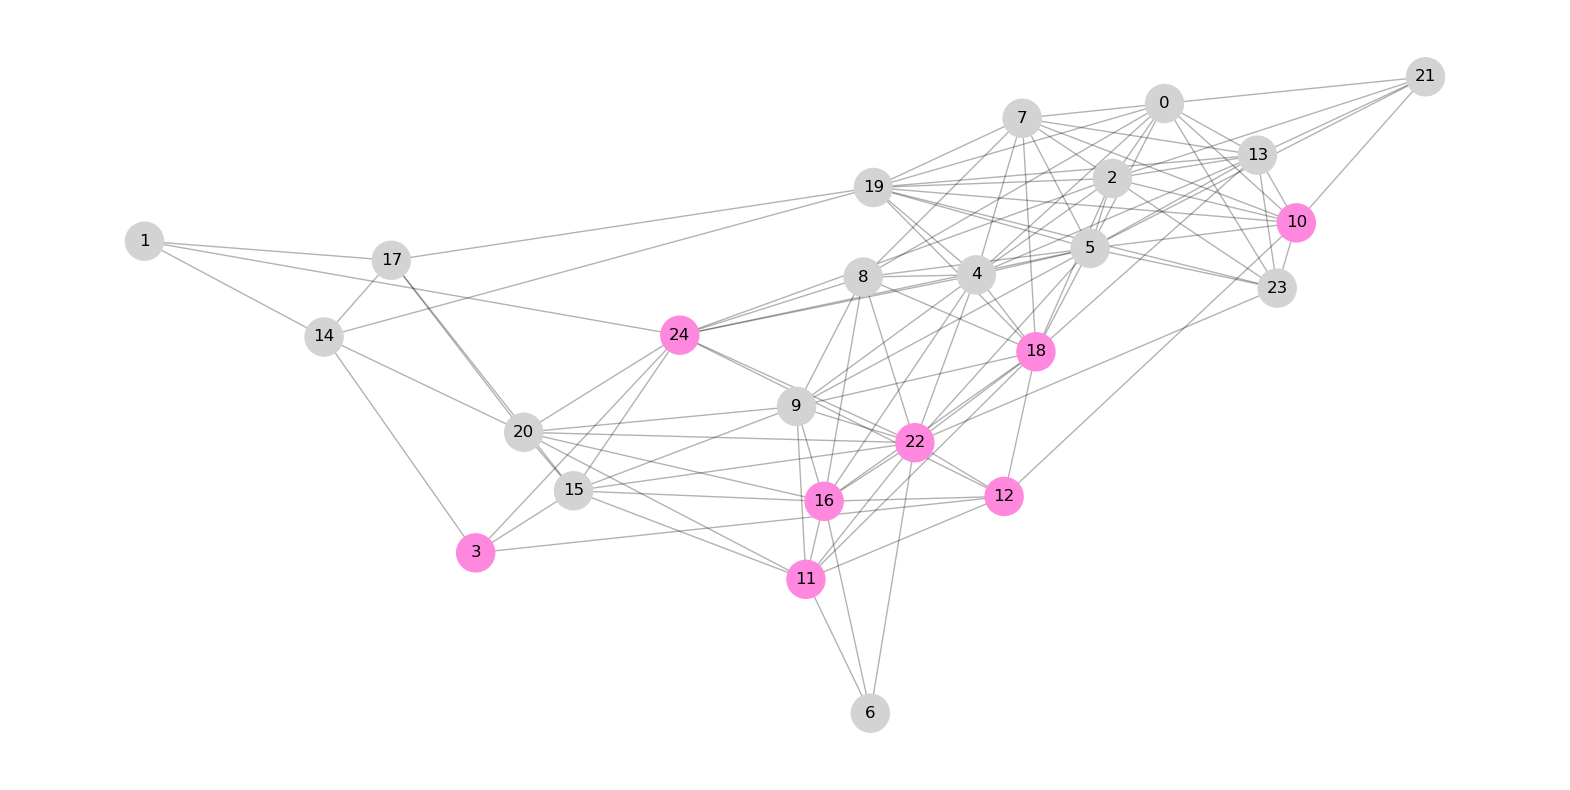

In [7]:
v = 12

neighbors = sorted(g.neighbors(v))

N = [v] + neighbors

print("گره انتخابی:", v)
print(f"N[{v}] = {N}",", " f"|N[{v}]| = {len(N)}")

node_colors = []

for node in g.nodes():
    if node in N:
        node_colors.append("#FF88DF")
    else:
        node_colors.append("lightgray")


plt.figure(figsize=(20,10))
nx.draw_networkx_edges(g, pos, alpha=0.3)
nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=750)
nx.draw_networkx_labels(g, pos, font_size=12)

plt.axis("off")
#plt.savefig("/mnt/d/study/term8/پروژه/complex contagions/comp75/stage0.png", dpi=150, bbox_inches="tight")
plt.show()

گره‌های فعال اولیه: [12, 3, 10, 11, 16, 18, 22, 24]


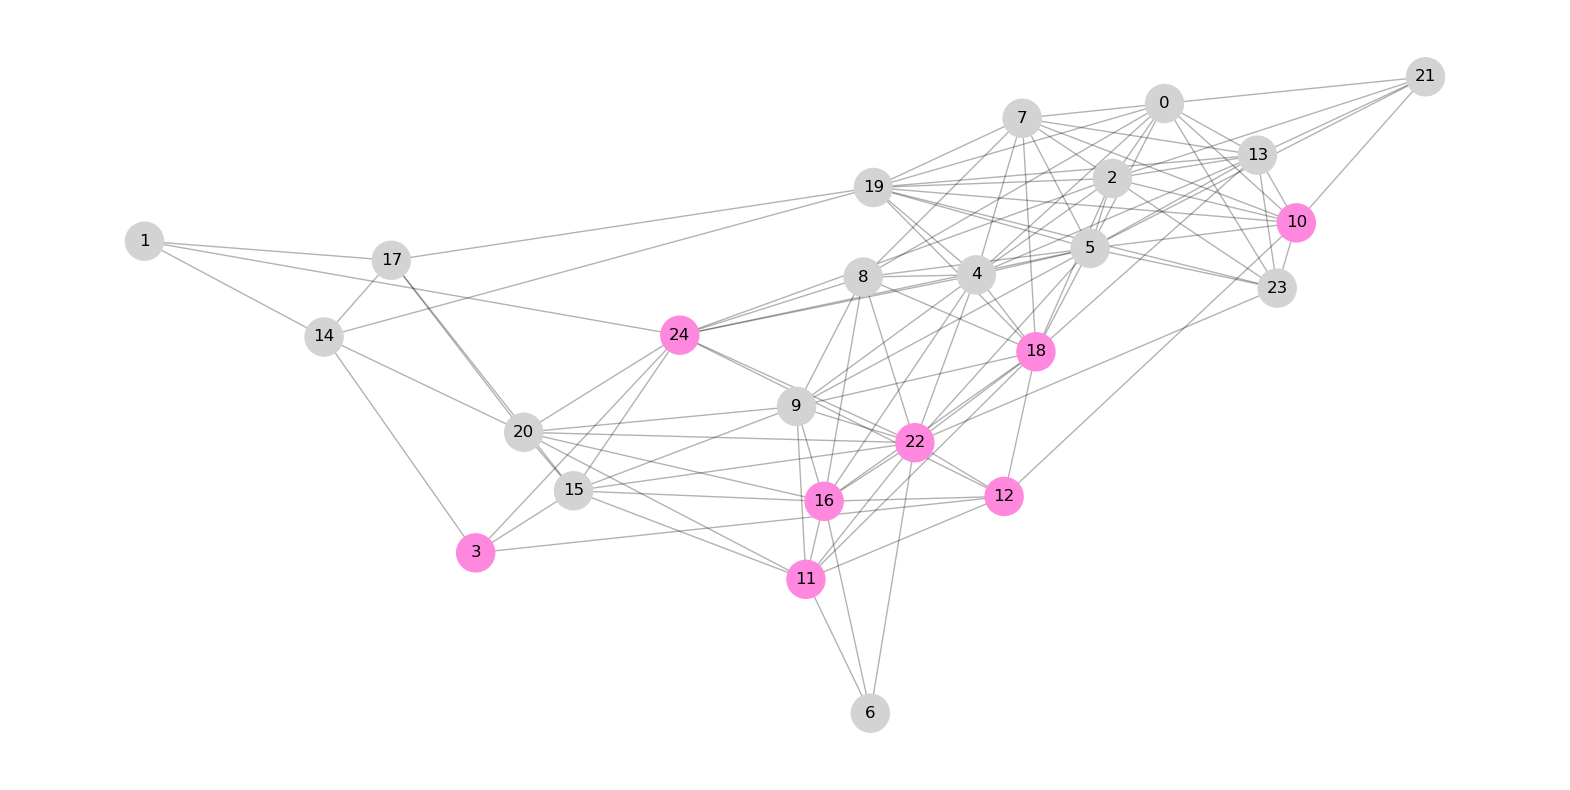

In [9]:
import random

Threshold = 4

k = Threshold - 1   # تعداد گره‌هایی که باید فعال شوند

#active_nodes = random.sample(neighbors, k)   # انتخاب تصادفی

#active_nodes = [11, 18, 22]   # انتخاب دستی

active_nodes = N   #تمام همسایگی گرۀ منتخب

#active_nodes.append(v)

print("گره‌های فعال اولیه:", active_nodes)

node_colors = []

for node in g.nodes():
    if node in active_nodes or node == v:
        node_colors.append("#FF88DF")      # فعال‌های اولیه
    else:
        node_colors.append("lightgray")    # بقیه

plt.figure(figsize=(20, 10))
nx.draw_networkx_edges(g, pos, alpha=0.3)
nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=750)
nx.draw_networkx_labels(g, pos, font_size=12)

plt.axis("off")
#plt.savefig("/mnt/d/study/term8/پروژه/complex contagions/75 graph/stage0.png", dpi=150, bbox_inches="tight")
plt.show()        

--------------------------------
مرحله 1
گره‌های فعال شده: [4, 5, 8, 9, 15, 20]


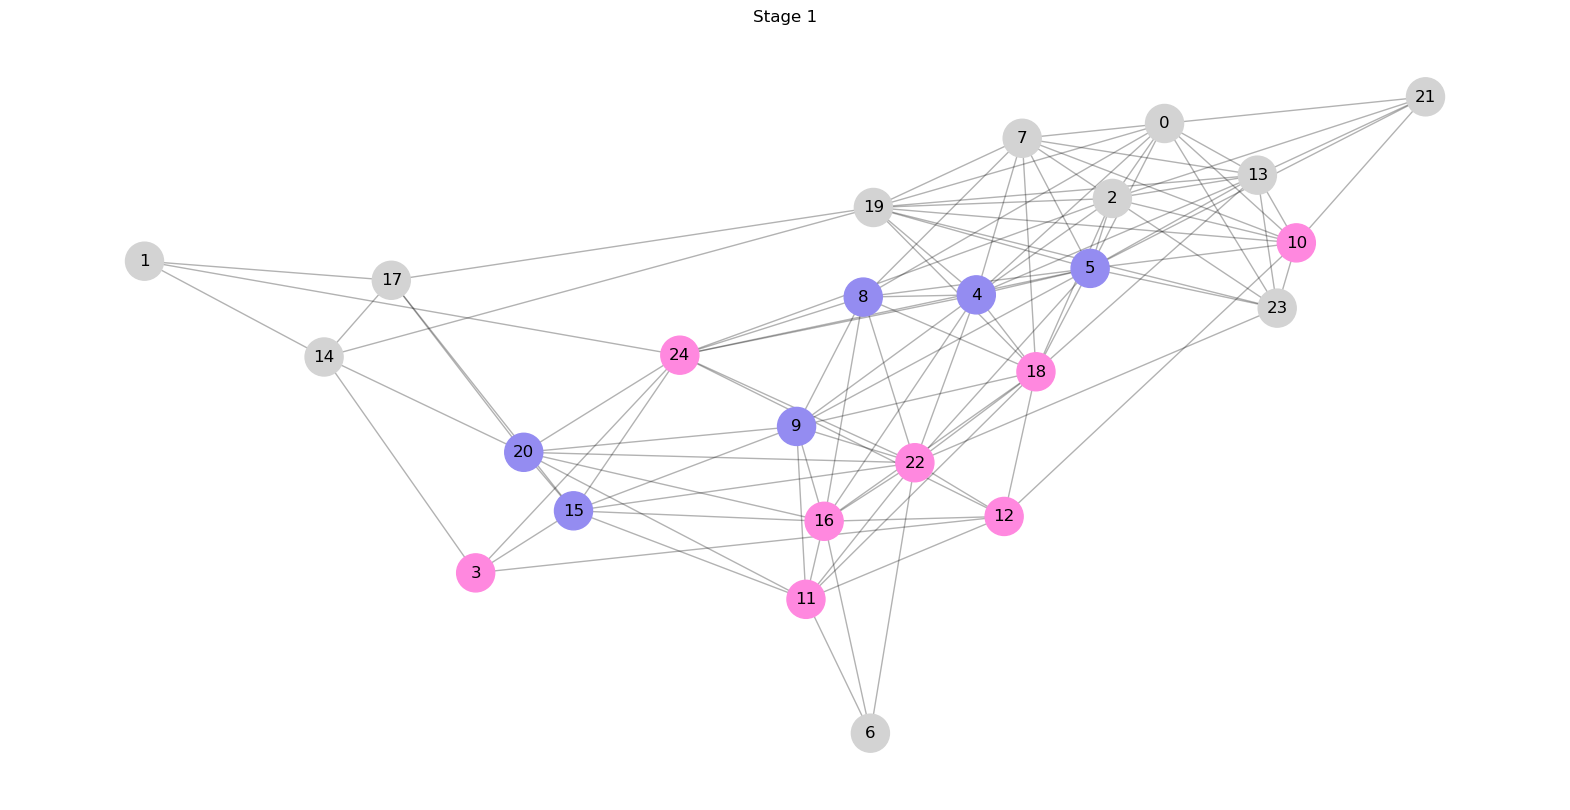

--------------------------------
مرحله 2
گره‌های فعال شده: [0, 2, 7, 13, 19]


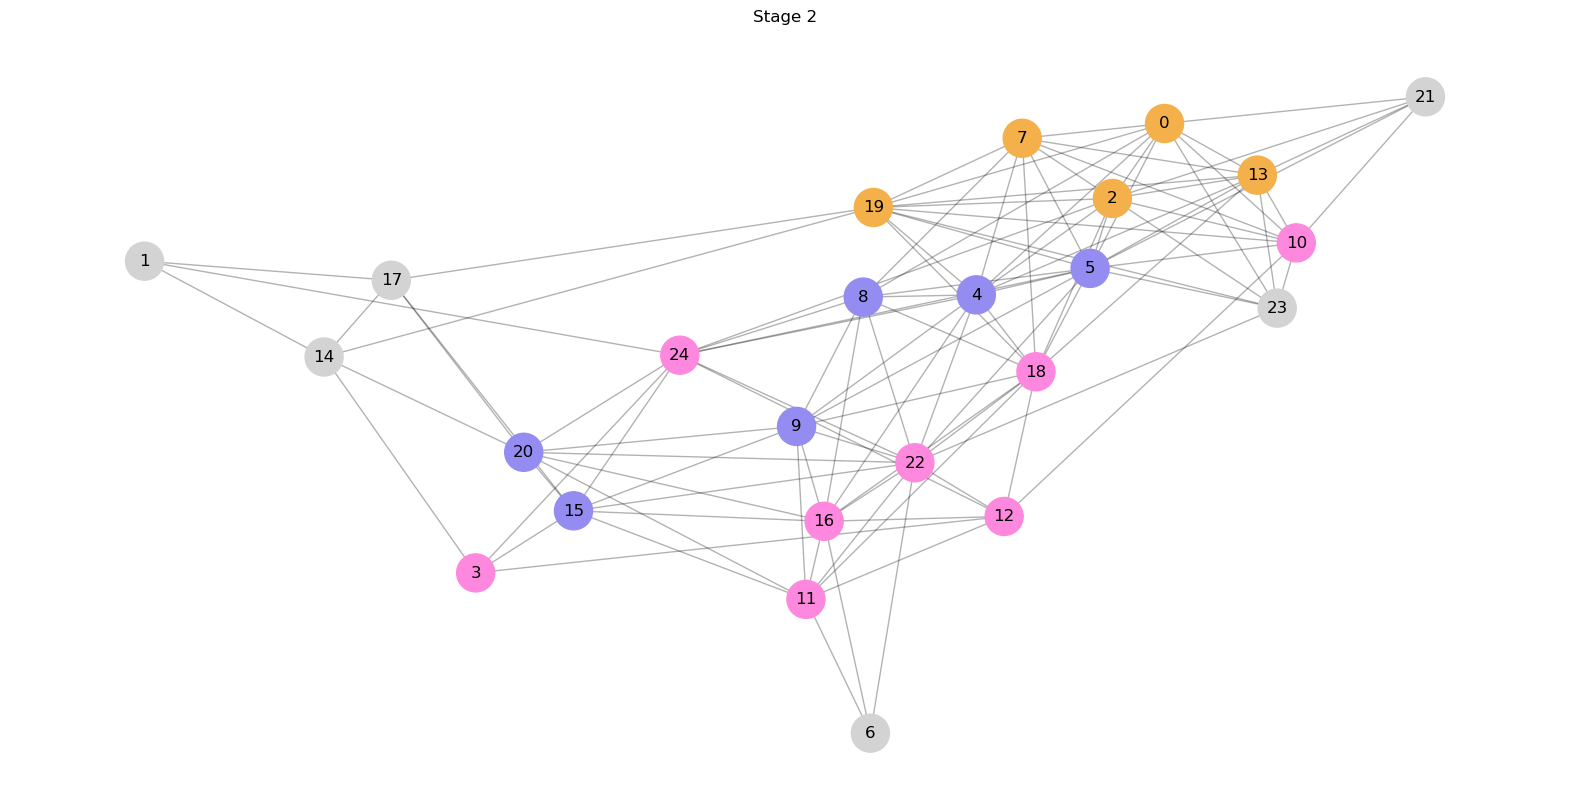

--------------------------------
مرحله 3
گره‌های فعال شده: [21, 23]


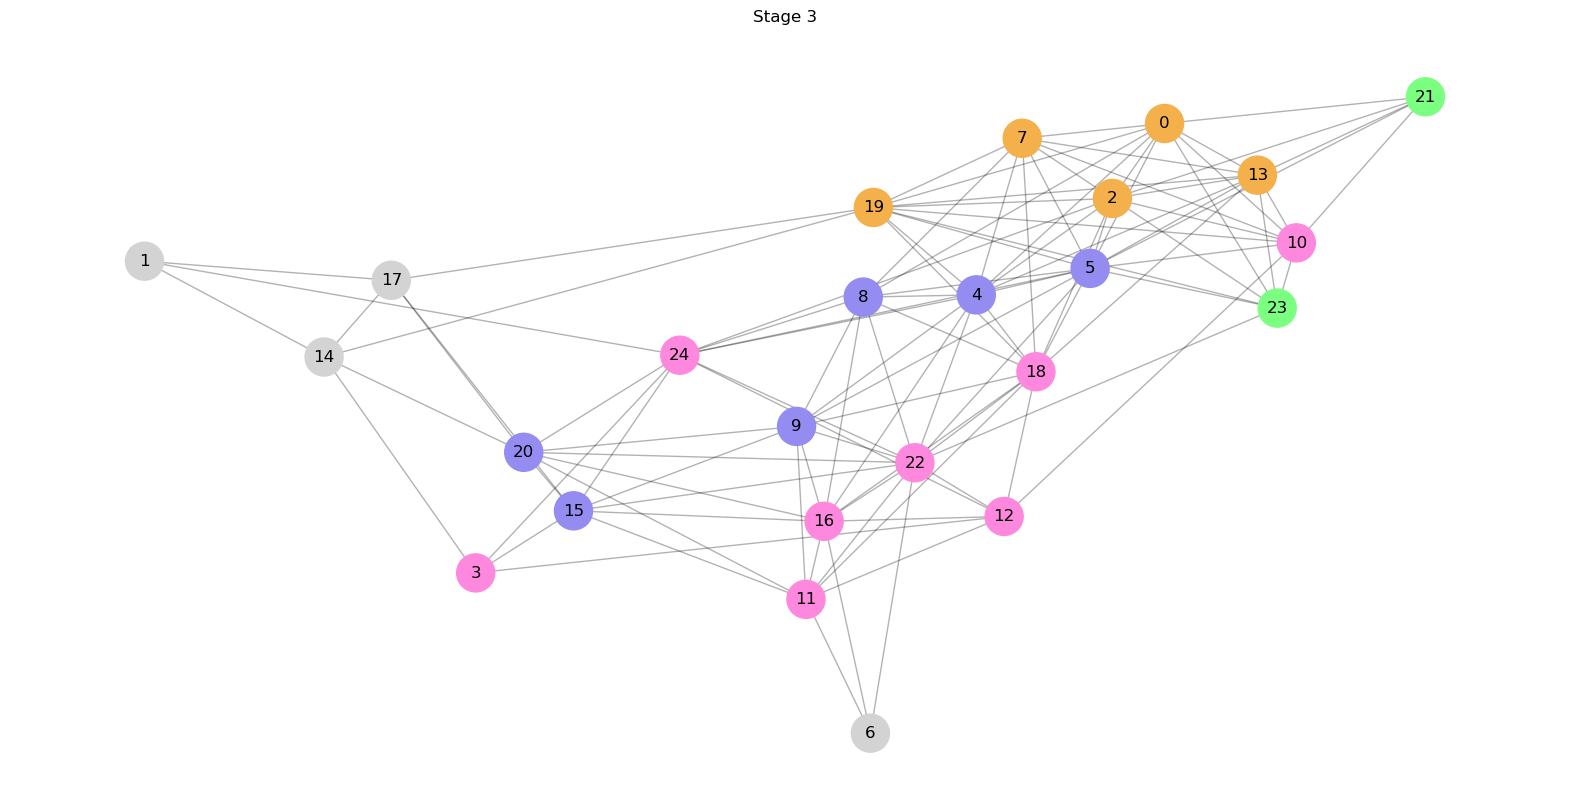

--------------------------------
فرآیند انتشار به پایان رسید.


In [10]:
# رنگ هر مرحله
stage_colors = [
    "#FF88DF",   # مرحله صفر (v و همسایه‌های فعال اولیه)
    "#948CF1",   # مرحله اول
    "#F4B04B",   # مرحله دوم
    "#7BFF80",   # مرحله سوم
    "#8AD1EFFF",   # مرحله چهارم
    "#FF6B6B",   # مرحله پنجم
    "#B25F8B",   # مرحله ششم
    "#0008FF8F",   # مرحله هفتم
    "#B28F5F",   # مرحله هشتم
    "#789D79E2",   # مرحله نهم
]

# مرحله صفر
active_set = set(active_nodes)
active_set.add(v)

stages = [[v] + active_nodes]   # هر مرحله در این لیست ذخیره می‌شود. مرحله صفر شامل v و همسایه‌های فعال اولیه است

stage = 1   # شروع مرحله اول

while True:
    new_nodes = []

    for node in g.nodes():   # بررسی تمام گره‌های غیرفعال
        if node in active_set:   # اگه قبلا فعال شده باشه ازش میگذریم
            continue
        count = 0   # تعداد همسایه‌های فعال رو میشماره

        for neighbor in g.neighbors(node):
            if neighbor in active_set:
                count += 1
        if count >= Threshold:
            new_nodes.append(node)

    if len(new_nodes) == 0:    # اگر هیچ گره جدیدی فعال نشد، پایان
        print("--------------------------------")
        print("فرآیند انتشار به پایان رسید.")
        break

    print("--------------------------------")    # چاپ خروجی این مرحله
    print(f"مرحله {stage}")
    print("گره‌های فعال شده:", sorted(new_nodes))

    stages.append(new_nodes)    # ذخیره مرحله

    active_set.update(new_nodes)    # فعال شدن گره‌ها

    # رسم
    node_colors = []

    for node in g.nodes():

        color = "lightgray"

        for i, layer in enumerate(stages):
            if node in layer:
                if i < len(stage_colors):
                    color = stage_colors[i]
                else:
                    color = stage_colors[-1]
                break

        node_colors.append(color)

    plt.figure(figsize=(20, 10))
    nx.draw_networkx_edges(g, pos, alpha=0.3)
    nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=750)
    nx.draw_networkx_labels(g, pos, font_size=12)

    plt.title(f"Stage {stage}")
    plt.axis("off")
    #plt.savefig(f"/mnt/d/study/term8/پروژه/complex contagions/75 graph/stage{stage}.png", dpi=150, bbox_inches="tight")
    plt.show()

    stage += 1

گره‌هایی که از Cascade به صورتی تبدیل شدند:
[]


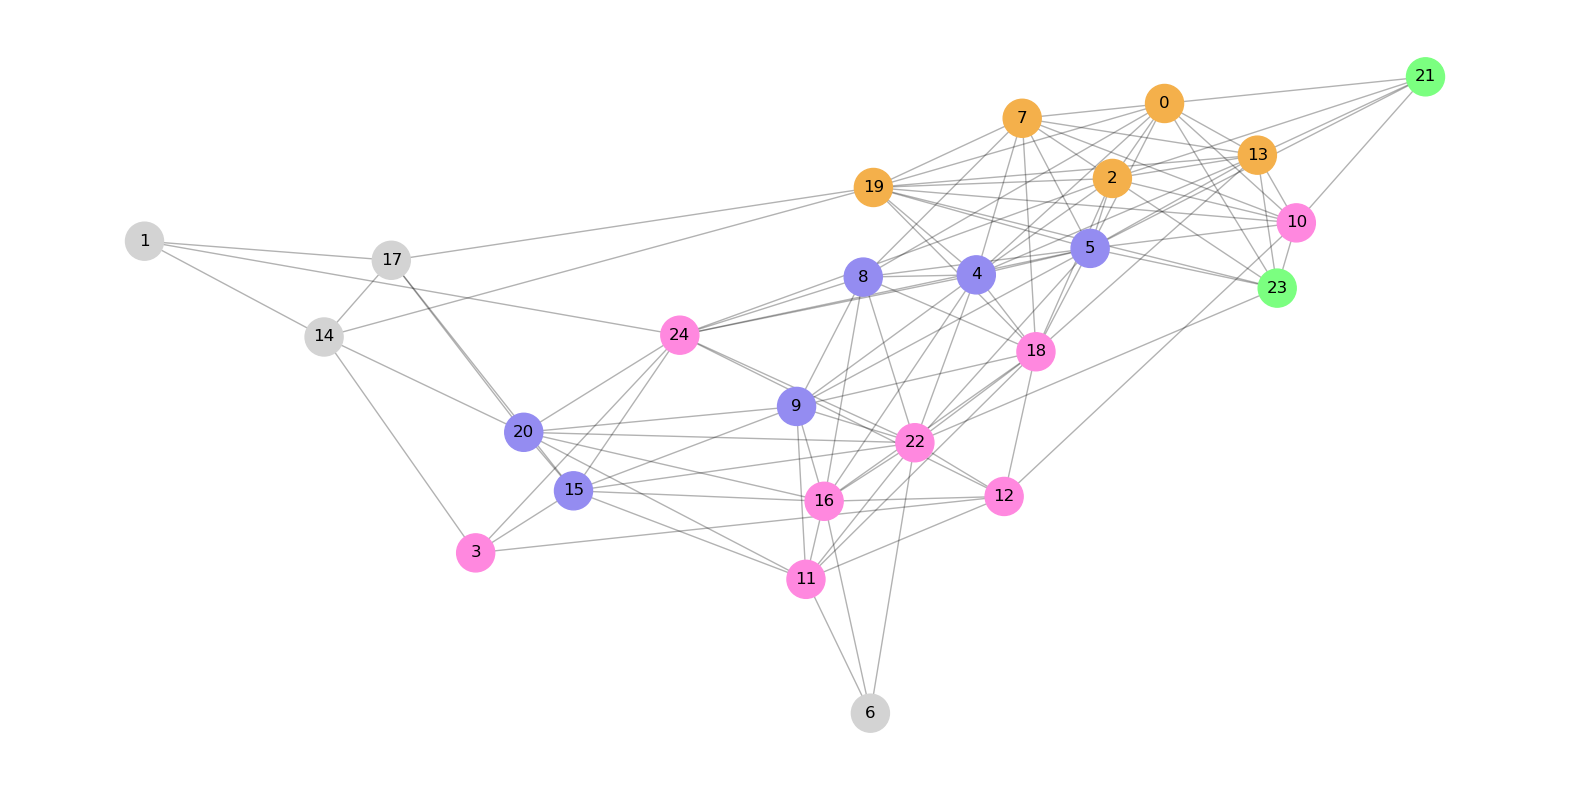


گره‌های فعال غیرصورتی:
[0, 2, 4, 5, 7, 8, 9, 13, 15, 19, 20, 21, 23]

Shortest Paths:

12 -> 0 : [12, 10, 0]    Length = 2
12 -> 2 : [12, 10, 2]    Length = 2
12 -> 4 : [12, 16, 4]    Length = 2
12 -> 5 : [12, 10, 5]    Length = 2
12 -> 7 : [12, 10, 7]    Length = 2
12 -> 8 : [12, 16, 8]    Length = 2
12 -> 9 : [12, 11, 9]    Length = 2
12 -> 13 : [12, 10, 13]    Length = 2
12 -> 15 : [12, 3, 15]    Length = 2
12 -> 19 : [12, 10, 19]    Length = 2
12 -> 20 : [12, 11, 20]    Length = 2
12 -> 21 : [12, 10, 21]    Length = 2
12 -> 23 : [12, 10, 23]    Length = 2


In [11]:
# همسایه‌های مستقیم v که در Cascade فعال شده‌اند را صورتی کن
pink_nodes = set(active_nodes)   # مجموعه‌ی گره‌های صورتی

cascade_nodes = set()   # تمام گره‌های فعال Cascade

for layer in stages:
    cascade_nodes.update(layer)

neighbors_v = set(g.neighbors(v))   # همسایه‌های مستقیم v

# همسایه‌هایی که فعال شده‌اند ولی هنوز صورتی نیستند
new_pink = []

for node in neighbors_v:
    if node in cascade_nodes and node not in pink_nodes:
        new_pink.append(node)

pink_nodes.update(new_pink)   # اضافه شدن به صورتی‌ها
print("گره‌هایی که از Cascade به صورتی تبدیل شدند:")
print(sorted(new_pink))

# نمایش گراف بعد از صورتی شدن گره‌های جدید
node_colors = []

for node in g.nodes():

    # صورتی‌ها (قدیمی + جدید)
    if node in pink_nodes:
        color = stage_colors[0]

    else:
        color = "lightgray"

        # رنگ گره‌های فعال دیگر بر اساس مرحله‌ی فعال شدن
        for i, layer in enumerate(stages):
            if node in layer:
                if i < len(stage_colors):
                    color = stage_colors[i]
                else:
                    color = stage_colors[-1]
                break

    node_colors.append(color)

plt.figure(figsize=(20, 10))
nx.draw_networkx_edges(g, pos, alpha=0.3)
nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=750)
nx.draw_networkx_labels(g, pos, font_size=12)

#plt.title(f"Graph after promoting neighbors of node {v} to pink")
plt.axis("off")
#plt.savefig("/mnt/f/test/TurnPink.png", dpi=150, bbox_inches="tight")
plt.show()

remaining_active = cascade_nodes - pink_nodes   # گره‌های فعالی که هنوز صورتی نیستند

print("\nگره‌های فعال غیرصورتی:")
print(sorted(remaining_active))

active_graph = g.subgraph(cascade_nodes)   # کوتاه‌ترین مسیر از v فقط برای گره‌های فعال غیرصورتی و فقط اگر طول مسیر > 1 باشد

print("\nShortest Paths:\n")

for node in sorted(remaining_active):

    try:
        path = nx.shortest_path(active_graph, source=v, target=node)
        length = len(path) - 1

        if length > 1:
            print(f"{v} -> {node} : {path}    Length = {length}")

    except nx.NetworkXNoPath:
        print(f"{v} -> {node} : No Path")